In [29]:
# Implying Non Negative Least Squares method to restore sky image

import numpy as np
A = np.loadtxt("shadows_matrix.txt")
A = A.T
d = np.loadtxt("dph1.txt")
noise = np.random.rand(256)
d_noisy = d + 0.1*noise
print(A.shape)
#print(d)

(256, 961)


In [30]:
import scipy as sp
from scipy import optimize
from scipy.optimize import nnls

In [38]:
c, residual = nnls(A, d)

In [39]:
print(c.shape)
idx = np.argsort(c)[::-1]
for i in idx[:10]:
    print(i, c[i])

(961,)
50 29.99999999999999
512 15.000000000000009
1 2.824750244596304e-14
21 6.015816040595784e-16
7 5.722262235986869e-16
35 5.623239845297972e-16
49 4.674701302235151e-16
958 2.3764961042605805e-16
959 2.3288217205293044e-16
32 2.0388401959808384e-16


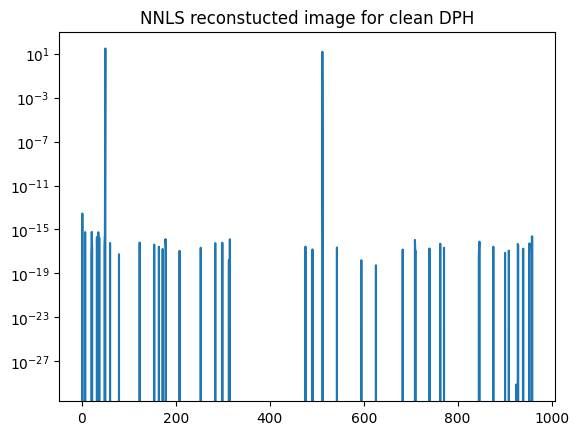

In [41]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(c)
plt.yscale("log")
plt.title("NNLS reconstucted image for clean DPH")
plt.show()


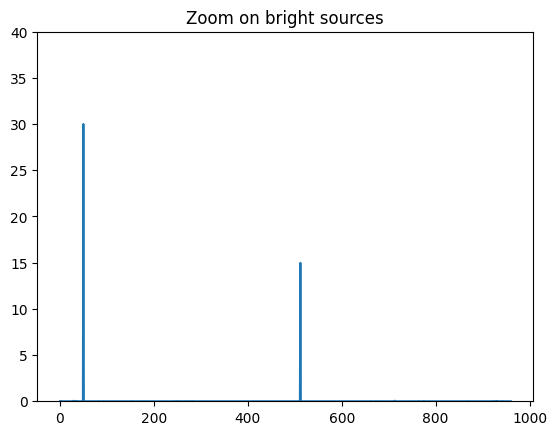

In [34]:
plt.figure()
plt.plot(c)
plt.ylim(0, 40)   # or 0–35 or 0–50
plt.title("Zoom on bright sources")
plt.show()


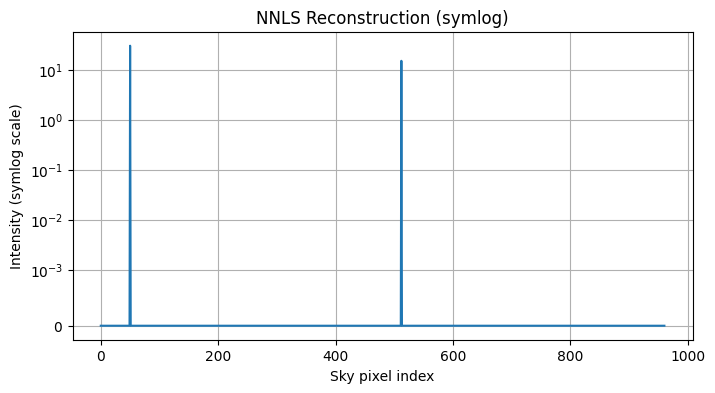

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(c)
plt.yscale("symlog", linthresh=1e-3)
plt.xlabel("Sky pixel index")
plt.ylabel("Intensity (symlog scale)")
plt.title("NNLS Reconstruction (symlog)")
plt.grid(True)
plt.show()

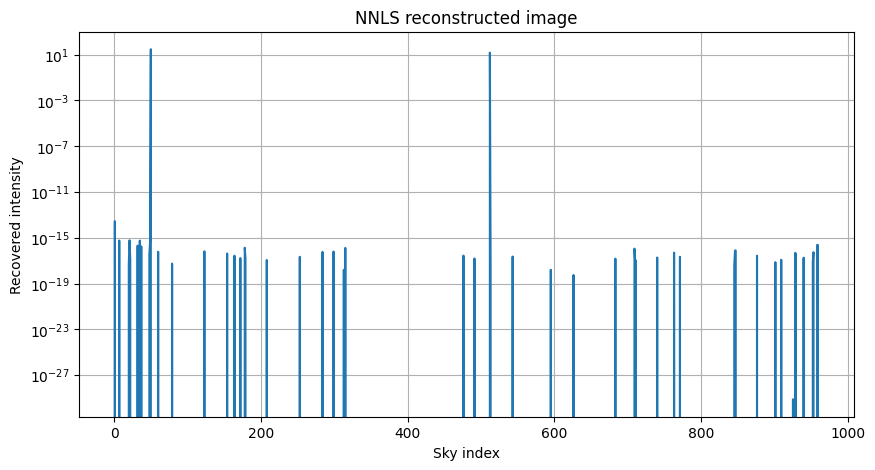

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.semilogy(c)
plt.xlabel("Sky index")
plt.ylabel("Recovered intensity")
plt.title("NNLS reconstructed image")
plt.grid(True)
plt.show()

In [6]:
np.savetxt("nnls_image.txt",
           np.column_stack((np.arange(961), c)),
           fmt="%4d %14.8e")

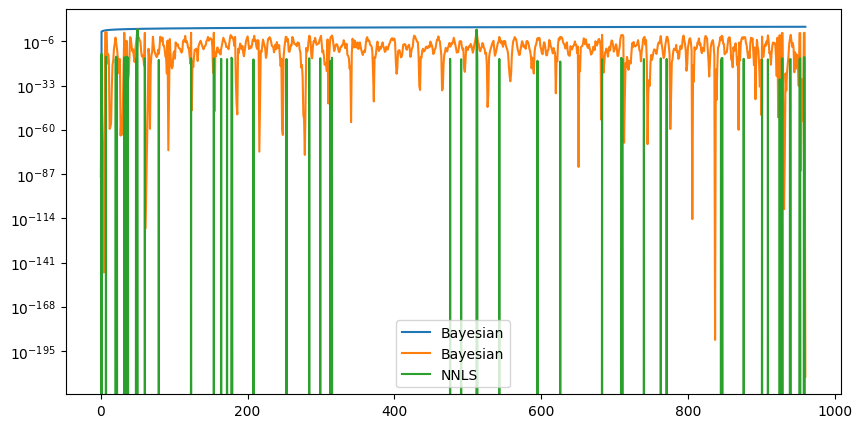

In [21]:
# Comparing with Bayesian

image_bayes = np.loadtxt("final_image.txt")
plt.figure(figsize=(10,5))
plt.semilogy(image_bayes, label="Bayesian")
plt.semilogy(c, label="NNLS")
plt.legend()
plt.show()